<a href="https://colab.research.google.com/github/Saphythrix/U-Net/blob/main/U_Net_Architecture_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-learn tqdm

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
import shutil

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sayantandas004","key":"71378c2d254fa18d70bcde4ca10124f6"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!cp /content/kaggle.json ~/.kaggle/

In [ ]:
!kaggle competitions download -c data-science-bowl-2018

100% 358M/358M [00:26<00:00, 14.4MB/s]



In [ ]:
import zipfile
zip_ref=zipfile.ZipFile('/content/data-science-bowl-2018.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
!unzip data-science-bowl-2018.zip

Archive:  data-science-bowl-2018.zip
replace stage1_sample_submission.csv.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!unzip stage1_train.zip

Streaming output truncated to the last 5000 lines.
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/160cf18b03df69978e2ed33335afcd781ebebf4ee42df566aaa6fd0aee66ac93.png  
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/16d3bf2426e9cda0e4f435de3a0c260d17be460f1c834c1282dfd68f9fcf7509.png  
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/1cfe69ef1dec8963e05ba8386a956af0073ba0bec2cc8ba534df81ef6dee905a.png  
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/1d2543cd2a8134ac2ca091a230bd15270826f8dd83c6594550b7f0fc85a15f8e.png  
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/24b50e6e3406e513d47ddfa9bd85505a95a266858cffc730a9ad7bc99936b800.png  
  inflating: d35f25c8e3f7fca5232fc4d5e3faf14b025b20b3731af77fe971a5e2e9d69d28/masks/341193ff7f035f118eabe993464e402c5485ff014e095ff5e940a0d960270737.png  
  inflating: d35f25

In [ ]:
!ls stage1_train

ls: cannot access 'stage1_train': No such file or directory


In [ ]:
!ls

...
data-science-bowl-2018.zip
db45946a4412a2137674ec075b6892ccd682b77826aba618210569bbc65cf2b0
dbbfe08a52688d0ac8de9161cbb17cb201e3991aacab8ab8a77fe0e203a69481
dbe5ad05b6f87018159a3228c1d1725892a1bfb9fa9f8fcc2e8bfe70d69d0355
dd54adb80393de7769b9853c0aa2ee9b240905d0e99c59d4ccd99401f327aa05
ddf1bf458312de2895dd9cc5ce7ec9d334ad54c35edc96ad6001d20b1d8588d8
dec1764c00e8b3c4bf1fc7a2fda341279218ff894186b0c2664128348683c757
df33b11184427e05c8a450f921586685975fe975f57315e686a0f26fddb93db1
df53d0b6c2c4e45d759b2c474011e2b2b32552cd100ca4b22388ab9ca1750ee2
df5cdd0ebe1bdf8dc870bc294b8f08961e083bc7f9be69e268454aa9091808b9
df9a4212ecb67bb4e58eba62f293b91f9d6f1dde73e38fa891c75661d419fc97
e1bcb583985325d0ef5f3ef52957d0371c96d4af767b13e48102bca9d5351a9b
e216ec5063d3562b793e434c491051bd8867f6c2e571e41137c7c560cc0e6a03
e23e11414ee645b51081fb202d38b793f0c8ef2940f8228ded384899d21b02c2
e2d22d3d283915df8350d039278e314a23e6e8f2b41bdfc16df849e22dd13b36
e321cfa987e77c21373a0f8b1236c83d6636306949a82a7f5b07fc0838e

In [ ]:
import os
base_path = "/content"

for folder in os.listdir(base_path):
    print(folder)

.config
4c032609d377bd980e01f888e0b298600bf8af0e33c4271a1f3aaf76964dce06
2ad489c11ed8b77a9d8a2339ac64ffc38e79281c03a2507db4688fd3186c0fe5
3852c7e45bd885b9537e276861ab50b99bb42f0f8e717d2f88174c62862ca3ff
03f583ec5018739f4abb9b3b4a580ac43bd933c4337ad8877aa18b1dfb59fc9a
8f6597cd978c060378177df76e554d0578b97eab471e237dbe0adc0dd0d93d63
3477024fd843e46097840360f9cdee24b76bf5c593ed27a9aee7a5728a06aa51
feffce59a1a3eb0a6a05992bb7423c39c7d52865846da36d89e2a72c379e5398
63d981a107091e1e3059102ce08870744dde173afe324bc2274c17d42f661778
317832f90f02c5e916b2ac0f3bcb8da9928d8e400b747b2c68e544e56adacf6b
c043d5ac9dd466052e53491d0d513b0684f493d320b820f6dc2e05330ce58ec3
b82548ab19466b461614e6055aaf49fbc24c03a2d20e65575b680c7c28268807
9ebcfaf2322932d464f15b5662cae4d669b2d785b8299556d73fffcae8365d32
0acd2c223d300ea55d0546797713851e818e5c697d073b7f4091b96ce0f3d2fe
4590d7d47f521df62f3bcb0bf74d1bca861d94ade614d8afc912d1009d607b94
c169a7782a69ea2f38f64d2739de189e88adbcfd4a829721def8c89ecabe8b71
20c37b1ad2f510ed7

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [ ]:
IMG_SIZE=256
base_path = "/content"

Function to combine masks

In [ ]:
def combine_masks(mask_path):
    mask_files = os.listdir(mask_path)
    combined_mask = None

    for file in mask_files:
        mask = cv2.imread(os.path.join(mask_path, file), 0)  # ✅ FIXED

        if combined_mask is None:
            combined_mask = mask
        else:
            combined_mask = np.maximum(combined_mask, mask)

    return combined_mask

In [ ]:
images=[]
masks=[]

for folder in tqdm(os.listdir(base_path)):
  path=os.path.join(base_path,folder)

  if not os.path.isdir(path):
        continue
  img_path=os.path.join(path,"images")
  mask_path=os.path.join(path,"masks")

  if not os.path.exists(img_path) or not os.path.exists(mask_path):
        continue

  image_file=os.listdir(img_path)[0]
  image=cv2.imread(os.path.join(img_path,image_file))
  image=cv2.resize(image,(IMG_SIZE,IMG_SIZE))

  mask=combine_masks(mask_path)
  mask=cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

  images.append(image)
  masks.append(mask)

100%|██████████| 682/682 [00:23<00:00, 28.86it/s]


In [ ]:
X=np.array(images,dtype=np.float32)
Y=np.array(masks,dtype=np.float32)

In [ ]:
X_max = X.max()
X_min = X.min()
X = (X - X_min) / (X_max - X_min)

# Normalize Y to [0, 1] (assuming it's binary 0 and 255)
Y = Y / 255.0  # Keep this one - it converts binary masks to [0, 1]

print(f"X range: [{X.min()}, {X.max()}]")
print(f"Y range: [{Y.min()}, {Y.max()}]")

X range: [0.0, 1.0]
Y range: [0.0, 1.0]


In [ ]:
Y=np.expand_dims(Y,axis=-1)

In [ ]:
X.shape

(670, 256, 256, 3)

In [ ]:
Y.shape

(670, 256, 256, 1)

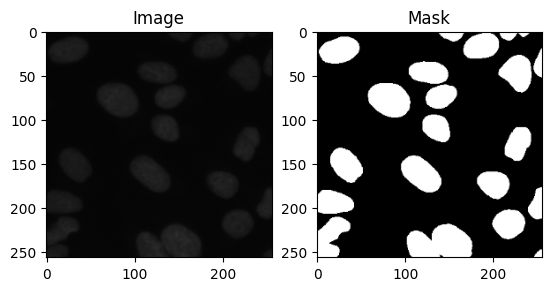

In [ ]:
import matplotlib.pyplot as plt

i = 0

plt.subplot(1,2,1)#(row,column,index)
plt.imshow(X[i])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[i].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
# Normalize based on actual data range, not assumed 0-255
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Get the actual max value from training data
X_max = X_train.max()  # Should be around 137
X_min = X_train.min()  # Should be around 1

# Normalize to [0, 1] using actual range
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

print(f"X_train normalized range: [{X_train.min()}, {X_train.max()}]")
print(f"X_test normalized range: [{X_test.min()}, {X_test.max()}]")

X_train normalized range: [0.0, 1.0]
X_test normalized range: [0.0, 1.0]


In [ ]:
from keras.models import Model
from keras.layers import Input,Conv2D,MaxPooling2D,UpSampling2D,Concatenate,Conv2DTranspose,BatchNormalization,Dropout
from keras.optimizers import Adam
from keras.regularizers import l2

Convolution block

In [ ]:
def conv_block(inputs_tensor,num_filters):
  x=Conv2D(num_filters,3,padding="same",activation='relu',kernel_regularizer=l2(1e-4))(inputs_tensor)
  x=BatchNormalization()(x)
  x=Dropout(0.5)(x)

  x=Conv2D(num_filters,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4))(x)
  x=BatchNormalization()(x)
  x=Dropout(0.5)(x)

  return x

Encoder block=Convolution layers+Max Pooling

In [ ]:
def encoder_block(inputs_tensor,num_filters):
  x=conv_block(inputs_tensor,num_filters)
  p=MaxPooling2D((2,2))(x)

  return x,p

Decoder Block= Upsampling + concatination+ 2 convolution layer

In [ ]:
def decoder_block(inputs_tensor,skip_features,num_filters):
  x=Conv2DTranspose(num_filters,(2,2),strides=2,padding="same")(inputs_tensor)
  x=Concatenate()([x,skip_features])
  x=conv_block(x,num_filters)

  return x

Building the U-Net Model

In [ ]:
from flax.nnx.nn.recurrent import Output
def build_unet(input_shape):
  inputs=Input(input_shape)

  s1,p1=encoder_block(inputs,16)
  s2,p2=encoder_block(p1,32)
  s3,p3=encoder_block(p2,64)
  s4,p4=encoder_block(p3,128)

  b1=conv_block(p4,256)

  d1=decoder_block(b1,s4,128)
  d2=decoder_block(d1,s3,64)
  d3=decoder_block(d2,s2,32)
  d4=decoder_block(d3,s1,16)

  outputs=Conv2D(1,1,padding="same",activation="sigmoid")(d4)

  model=Model(inputs,outputs,name="U-Net")

  return model

In [ ]:
from keras.callbacks import EarlyStopping

unet_model=build_unet((IMG_SIZE,IMG_SIZE,3))

unet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True
)

history = unet_model.fit(
    X_train, Y_train,
    epochs=25,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop],
    batch_size=8, # Added batch_size to reduce memory usage during training
    verbose=1
)

Epoch 1/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 62s 223ms/step - accuracy: 0.4864 - loss: 1.0442 - val_accuracy: 0.1346 - val_loss: 0.9117
Epoch 2/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.5555 - loss: 0.9421 - val_accuracy: 0.1346 - val_loss: 1.0082
Epoch 3/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6169 - loss: 0.8802 - val_accuracy: 0.1346 - val_loss: 1.0901
Epoch 4/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.6605 - loss: 0.8369 - val_accuracy: 0.6035 - val_loss: 1.0122
Epoch 5/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.7022 - loss: 0.7706 - val_accuracy: 0.4507 - val_loss: 1.0888
Epoch 6/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.7271 - loss: 0.7362 - val_accuracy: 0.4538 - val_loss: 0.7437
Epoch 7/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.7764 - loss: 0.6605 - val_accuracy: 0.8341 - val_loss: 0.4821
Epoch 8/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.8257 - loss: 0.5954 - val_accuracy: 0.8691 

In [ ]:
Y_pred=unet_model.predict(X_test, batch_size=1) # Reduce batch_size further to avoid memory exhaustion

134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [ ]:
preds_binary = (Y_pred > 0.5).astype(np.uint8)

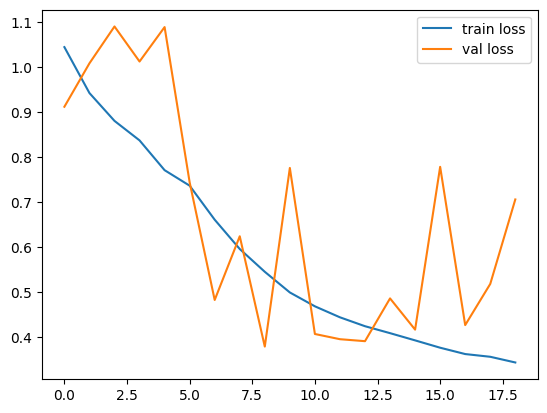

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction range: [0.008807411417365074, 0.9999488592147827]
Prediction mean: 0.2956514358520508
% pixels > 0.5: 17.9534912109375%


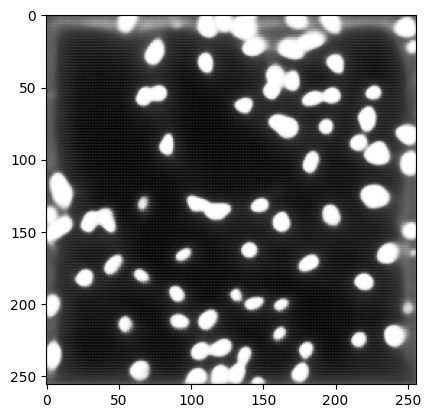

In [ ]:
# Check raw model output
test_img = X_test[0:1]
pred = unet_model.predict(test_img)

print(f"Prediction range: [{pred.min()}, {pred.max()}]")
print(f"Prediction mean: {pred.mean()}")
print(f"% pixels > 0.5: {(pred > 0.5).mean() * 100}%")

# Visualize
plt.imshow(pred[0, :, :, 0], cmap='gray')
plt.show()


Sample 0:
  Input range: [0.0313725508749485, 0.9764705896377563]
  Prediction range: [0.008807411417365074, 0.9999488592147827]
  % > 0.5: 17.9534912109375%


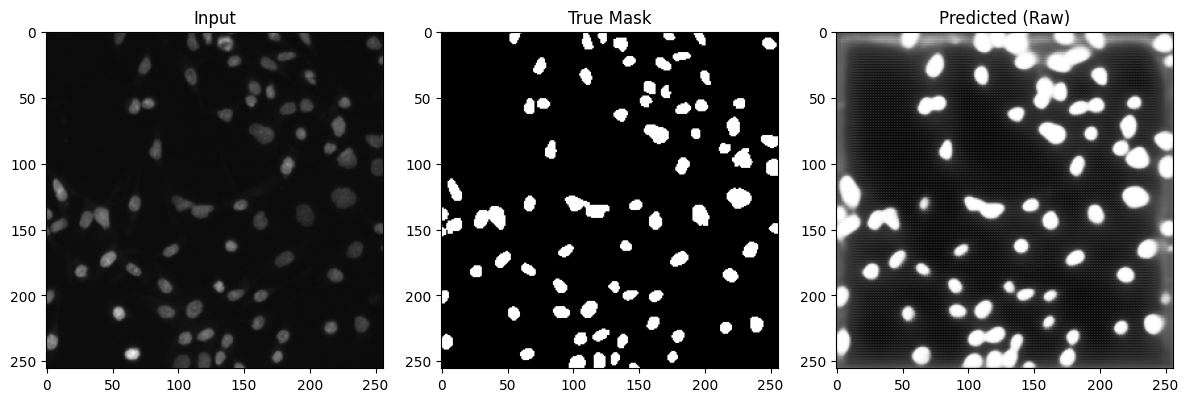


Sample 1:
  Input range: [0.03529411926865578, 1.0]
  Prediction range: [0.005630625411868095, 0.9999133348464966]
  % > 0.5: 10.57891845703125%


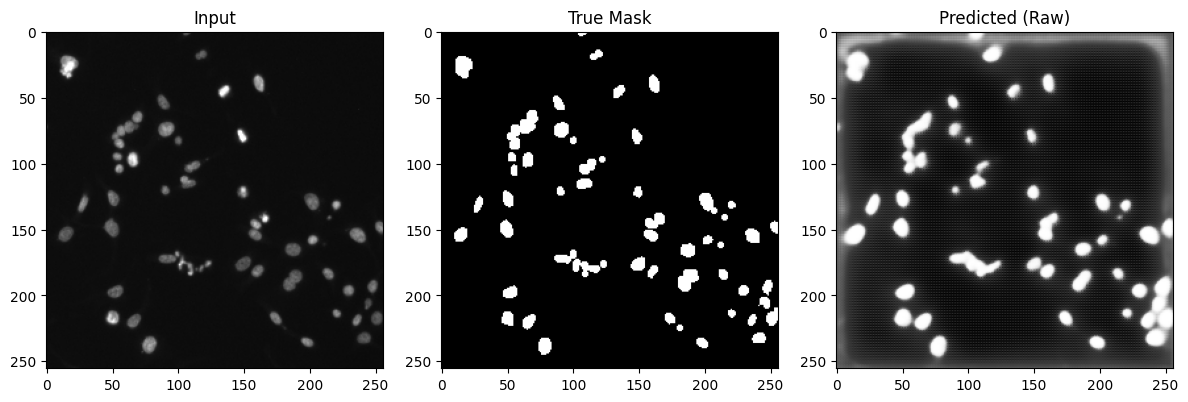


Sample 2:
  Input range: [0.003921568859368563, 0.4313725531101227]
  Prediction range: [0.004697192460298538, 0.9998819828033447]
  % > 0.5: 11.9354248046875%


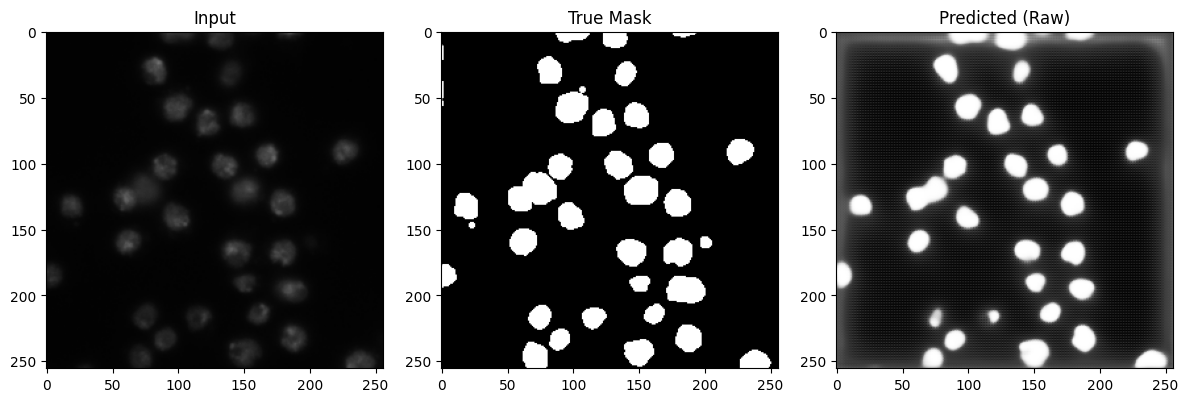

In [ ]:
# Get predictions on multiple test samples
for i in range(3):
    test_img = X_test[i:i+1]
    pred = unet_model.predict(test_img, verbose=0)

    print(f"\nSample {i}:")
    print(f"  Input range: [{test_img.min()}, {test_img.max()}]")
    print(f"  Prediction range: [{pred.min()}, {pred.max()}]")
    print(f"  % > 0.5: {(pred > 0.5).mean() * 100}%")

    # Plot without thresholding
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(test_img[0], cmap='gray')
    axes[0].set_title('Input')
    axes[1].imshow(Y_test[i], cmap='gray')
    axes[1].set_title('True Mask')
    axes[2].imshow(pred[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[2].set_title('Predicted (Raw)')
    plt.tight_layout()
    plt.show()

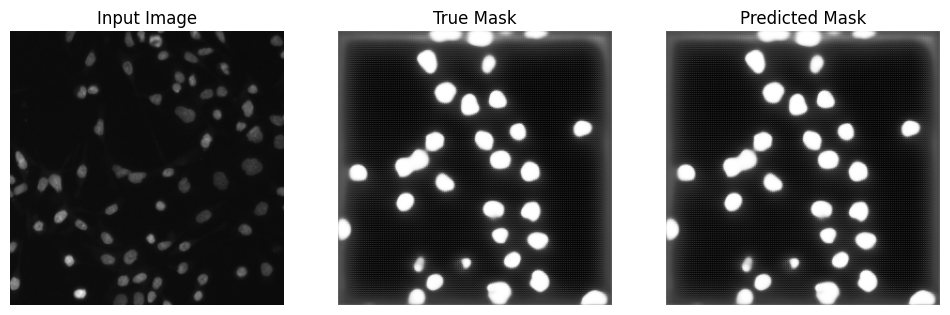

In [ ]:
import matplotlib.pyplot as plt

i = 0  # change index to see different samples

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(X_test[i])
plt.title("Input Image")
plt.axis("off")

# Ground Truth Mask
plt.subplot(1,3,2)
plt.imshow(pred[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title("True Mask")
plt.axis("off")

# Predicted Mask
plt.subplot(1,3,3)
plt.imshow(pred[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()